## Q1. Cap Stripping Mechanics

### Data Imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from scipy.stats import norm

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 15)

DATA_PATH = Path('Data')

In [25]:
# Load cap vol time series
cap_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='cap', index_col=0)
cap_maturities = cap_raw.loc['maturity'].astype(float)
cap_data = cap_raw.drop(index='maturity').astype(float)
cap_data.index = pd.to_datetime(cap_data.index)

# Round maturities to nearest year (BB reports e.g. 0.999 instead of 1.0)
cap_data.columns = (4 * cap_maturities.values).round(0) / 4
cap_data.columns.name = 'maturity'
cap_data = cap_data.T.drop_duplicates().T

# Load SOFR swap time series
sofr_raw = pd.read_excel(DATA_PATH / 'project_cap_vol_ts.xlsx', sheet_name='sofr', index_col=0)
sofr_maturities = sofr_raw.loc['maturity'].astype(float)
sofr_data = sofr_raw.drop(index='maturity').astype(float)
sofr_data.index = pd.to_datetime(sofr_data.index)
sofr_data.columns = (12 * sofr_maturities.values).round(0) / 12
sofr_data.columns.name = 'maturity'
sofr_data = sofr_data.T.drop_duplicates().T
sofr_data = sofr_data / 100  # percent to decimal

# Load reference rates (SOFR daily)
ref_rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx', sheet_name='data')
ref_rates['date'] = pd.to_datetime(ref_rates['date'])
ref_rates = ref_rates.set_index('date').sort_index()

sofr_daily = ref_rates['SOFR'].dropna() / 100

# Load validation curves (for 2025-06-30, fully processed)
curves_validation = pd.read_excel(
    DATA_PATH / 'cap_curves_2025-06-30.xlsx',
    sheet_name='rate curves 2025-06-30'
).set_index('tenor')


In [26]:
cap_data.head(5)

maturity,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
date,,,,,,,,,,
2022-03-17,127.3,108.5,109.9,108.5,107.3,104.3,101.0,97.7,95.2,93.2
2022-03-18,96.2,104.9,108.0,108.5,108.0,105.0,101.8,98.3,95.4,93.4
2022-03-21,96.2,105.0,108.1,108.5,107.9,105.0,101.7,98.2,95.4,93.4
2022-03-22,75.1,108.3,115.2,115.3,113.6,109.9,106.3,102.8,99.9,97.5
2022-03-23,94.1,111.0,117.9,117.1,114.6,110.7,107.2,103.5,100.5,98.1


In [27]:
sofr_data.head(5)

maturity,0.25,0.50,0.75,1.00,1.25,1.50,1.75,...,4.50,5.00,6.00,7.00,8.00,9.00,10.00
date,,,,,,,,,,,,,,,
2022-01-03,0.000907,0.002001,0.003068,0.004059,0.004970,0.005920,0.006795,...,0.011550,0.012022,0.012636,0.013149,0.013567,0.013908,0.014237
2022-01-04,0.000908,0.001974,0.002980,0.003949,0.004875,0.005808,0.006670,...,0.011560,0.011996,0.012663,0.013228,0.013667,0.014028,0.014370
2022-01-05,0.000982,0.002180,0.003313,0.004400,0.005390,0.006395,0.007355,...,0.012295,0.012746,0.013410,0.013943,0.014349,0.014678,0.014994
2022-01-06,0.001118,0.002390,0.003569,0.004630,0.005655,0.006670,0.007650,...,0.012745,0.013161,0.013794,0.014285,0.014654,0.014946,0.015240
2022-01-07,0.001143,0.002373,0.003505,0.004584,0.005625,0.006660,0.007665,...,0.013020,0.013440,0.014133,0.014665,0.015058,0.015354,0.015648


In [28]:
ref_rates.head(5)

,DTB3,DFF,SOFR
date,,,
2018-01-01,NaN,1.33,NaN
2018-01-02,1.42,1.42,NaN
2018-01-03,1.39,1.42,NaN
2018-01-04,1.39,1.42,NaN
2018-01-05,1.37,1.42,NaN


In [29]:
curves_validation.head(5)

,swap rates,spot rates,discounts,forwards,flat vols,fwd vols
tenor,,,,,,
0.25,0.042353,0.042353,0.989523,NaN,NaN,NaN
0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842
0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708
1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464
1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341


## Question 1: Cap Stripping Mechanics

a). Select a single date from the time series. Using that date’s cap flat vols and SOFR swap curve, build the full processing pipeline:

- Convert Bloomberg normal vols (bp) to Black vols

- Interpolate to a quarterly grid

- Construct discount and forward curves

- Bootstrap forward vols from flat vols

- Validate your pipeline against the processed ```cap_curves_2025-06-30.xlsx``` file.

b) Plot the flat vol and forward vol term structures side by side. The forward vol curve is typically humped: near-term vol reflects current policy uncertainty, while long-term vol reverts to a mean. Describe the shape you observe and explain why it looks that way given where the Fed was in its policy cycle on your chosen date.

c) Repeat Q1b on 3–4 dates spanning the rate cycle (e.g., mid-2022, mid-2023, mid-2024, mid-2025). How does the shape of the forward vol curve change across regimes?



## a)

In [30]:
cap_vols = cap_data.loc['2025-06-30']
SOFR_swaps = sofr_data.loc['2025-06-30']
ref = ref_rates.loc['2025-06-30', 'SOFR']


### Quarterly Interpolation of Swaps, Discount And Forwards 

In [66]:
quarterly_swaps = pd.Series(index=np.arange(0.25, 10.25, 0.25), dtype=float)
quarterly_swaps.loc[SOFR_swaps.index] = SOFR_swaps.values
quarterly_swaps = quarterly_swaps.interpolate(method='index')

# ── Step 2: Bootstrap discount factors ───────────────────────────────────────
# SOFR swaps are annually compounded → convert to quarterly equivalent coupon
# c = (1+R)^0.25 - 1  is the correct per-period coupon for a quarterly swap
discount_factors = {}

for T in sorted(quarterly_swaps.index):
    R = quarterly_swaps[T]
    c = (1 + R) ** 0.25 - 1          # quarterly coupon from annual compound rate

    known_sum = sum(discount_factors[t] * c for t in discount_factors)
    discount_factors[T] = (1 - known_sum) / (1 + c)

discount_factors = pd.Series(discount_factors)

# ── Step 3: Bootstrap simple forward rates ───────────────────────────────────
# Simple rate convention: F = (DF_prev/DF_curr - 1) / dt
# This is consistent with Black's formula for caplets
forward_rates = {}
tenors = sorted(discount_factors.index)

for i in range(1, len(tenors)):
    T_prev = tenors[i - 1]
    T_curr = tenors[i]
    dt = T_curr - T_prev              # = 0.25 throughout
    forward_rates[(T_prev, T_curr)] = (
        discount_factors[T_prev] / discount_factors[T_curr] - 1
    ) / dt

forward_rates = pd.Series(forward_rates)

# ── Step 4: Convert strikes to simple rate convention ────────────────────────
# Must match the convention of forward_rates before passing to Black's formula
K_simple = quarterly_swaps.copy()
K_simple = ((1 + K_simple) ** 0.25 - 1) / 0.25


#### Quarterly Black Vol Interpolation

In [32]:
black_vols = {}
for maturity in cap_vols.index:
    normal_vol = cap_vols[maturity] / 10000
    T_prev = round(maturity - 0.25, 2)
    F = forward_rates.get((T_prev, maturity), np.nan)  # forward ending at cap maturity
    black_vols[maturity] = normal_vol / F
 
quarterly_vols = pd.Series(index = np.arange(0.5, 10.25, 0.25))
quarterly_vols.loc[black_vols.keys()] = pd.Series(black_vols)
quarterly_vols = quarterly_vols.interpolate(method='index') 

#### Discount and Forward Interpolation

#### Bootstrapping Forward Vol

In [68]:
cap_prices = {}

for maturity in quarterly_vols.index:
    flat_vol = quarterly_vols.loc[maturity]
    caplet_maturities = np.arange(0.5, maturity + 0.25, 0.25)
    caplet_prices = []
    K = K_simple.loc[maturity]
    for T in caplet_maturities:
        T_expiry = T - 0.25
        forward_rate = forward_rates.get((T - 0.25, T), np.nan)
        discount_rate = discount_factors.get(T, np.nan)

        if np.isnan(forward_rate) or np.isnan(discount_rate):
            break

        d_1 = (np.log(forward_rate / K) + 0.5 * flat_vol**2 * (T_expiry)) / (flat_vol * np.sqrt(T_expiry))
        d_2 = d_1 - flat_vol * np.sqrt(T_expiry)

        caplet_price = discount_rate * (forward_rate * norm.cdf(d_1) - K * norm.cdf(d_2)) * 0.25
        caplet_prices.append(caplet_price)

    cap_prices[maturity] = sum(caplet_prices)

cap_prices = pd.Series(cap_prices)
display(cap_prices)

0.50          NaN
0.75          NaN
1.00     0.001143
1.25     0.001994
1.50     0.003031
1.75     0.004272
2.00     0.005748
2.25     0.006912
2.50     0.008163
2.75     0.009500
3.00     0.010917
3.25     0.012325
3.50     0.013759
3.75     0.015287
4.00     0.016842
4.25     0.018296
4.50     0.019749
4.75     0.021271
5.00     0.022792
5.25     0.024441
5.50     0.026103
5.75     0.027775
6.00     0.029456
6.25     0.031098
6.50     0.032738
6.75     0.034374
7.00     0.036004
7.25     0.037713
7.50     0.039421
7.75     0.041128
8.00     0.042831
8.25     0.044598
8.50     0.046366
8.75     0.048133
9.00     0.049899
9.25     0.051634
9.50     0.053363
9.75     0.055085
10.00    0.056800
dtype: float64

In [47]:
caplet_prices = cap_prices.diff().dropna()
display(caplet_prices)

1.25     0.000851
1.50     0.001037
1.75     0.001241
2.00     0.001476
2.25     0.001164
2.50     0.001252
2.75     0.001337
3.00     0.001417
3.25     0.001408
3.50     0.001434
3.75     0.001528
4.00     0.001556
4.25     0.001454
4.50     0.001453
4.75     0.001522
5.00     0.001521
5.25     0.001650
5.50     0.001662
5.75     0.001672
6.00     0.001680
6.25     0.001642
6.50     0.001640
6.75     0.001636
7.00     0.001630
7.25     0.001709
7.50     0.001709
7.75     0.001707
8.00     0.001703
8.25     0.001767
8.50     0.001768
8.75     0.001767
9.00     0.001766
9.25     0.001735
9.50     0.001729
9.75     0.001722
10.00    0.001715
dtype: float64

In [61]:
from scipy.optimize import brentq

def black_caplet_price(vol, F, K, T_expiry, discount, delta=0.25):
    if T_expiry <= 0 or vol <= 0:
        return 0
    d1 = (np.log(F / K) + 0.5 * vol**2 * T_expiry) / (vol * np.sqrt(T_expiry))
    d2 = d1 - vol * np.sqrt(T_expiry)
    return delta * discount * (F * norm.cdf(d1) - K * norm.cdf(d2))


def bootstrap_forward_vols(cap_prices, forward_rates, discount_factors, K_simple, flat_vols):
    forward_vols = {}
    sorted_maturities = sorted(cap_prices.dropna().index)
    first_maturity = sorted_maturities[0]  # = 1.0

    # ── Initialize: all caplets within the first cap get flat vol ──
    for T in np.arange(0.5, first_maturity + 0.25, 0.25):
        T = round(T, 2)
        forward_vols[T] = flat_vols.loc[first_maturity]  # e.g. 0.2030 for all T<=1.0

    # ── Bootstrap from second maturity onward ──
    for i in range(1, len(sorted_maturities)):
        T_curr = round(sorted_maturities[i], 2)
        T_prev = round(sorted_maturities[i-1], 2)

        K_new = K_simple.get(T_curr, np.nan)
        F_new = forward_rates.get((T_prev, T_curr), np.nan)
        discount_new = discount_factors.get(T_curr, np.nan)
        T_expiry_new = T_prev

        if any(np.isnan([K_new, F_new, discount_new])):
            forward_vols[T_curr] = np.nan
            continue

        # Re-price inner caplets at K_new using bootstrapped forward vols
        inner_caplets_repriced = 0.0
        for T in np.arange(0.5, T_curr, 0.25):
            T = round(T, 2)
            T_expiry = round(T - 0.25, 2)
            if T_expiry <= 0:
                continue

            fwd_vol = forward_vols.get(T, np.nan)
            F = forward_rates.get((T_expiry, T), np.nan)
            df = discount_factors.get(T, np.nan)

            if any(np.isnan([fwd_vol, F, df])):
                continue

            inner_caplets_repriced += black_caplet_price(fwd_vol, F, K_new, T_expiry, df)

        marginal_caplet_price = cap_prices[T_curr] - inner_caplets_repriced

        if marginal_caplet_price <= 0:
            forward_vols[T_curr] = np.nan
            continue

        try:
            fwd_vol = brentq(
                lambda v: black_caplet_price(v, F_new, K_new, T_expiry_new, discount_new) - marginal_caplet_price,
                1e-6, 5.0, xtol=1e-8
            )
        except ValueError:
            forward_vols[T_curr] = np.nan
            continue

        forward_vols[T_curr] = fwd_vol

    return pd.Series(forward_vols)

forward_vols = bootstrap_forward_vols(cap_prices, forward_rates, discount_factors, K_simple, quarterly_vols)

display(forward_vols)

0.50     0.203040
0.75     0.203040
1.00     0.203040
1.25     0.285992
1.50     0.312945
1.75     0.344836
2.00     0.382547
2.25     0.286393
2.50     0.288403
2.75     0.289245
3.00     0.289517
3.25     0.278976
3.50     0.276310
3.75     0.274853
4.00     0.272187
4.25     0.247061
4.50     0.240905
4.75     0.235881
5.00     0.229761
5.25     0.243307
5.50     0.239585
5.75     0.235859
6.00     0.232129
6.25     0.219134
6.50     0.214441
6.75     0.209741
7.00     0.205034
7.25     0.212020
7.50     0.208311
7.75     0.204596
8.00     0.200875
8.25     0.208092
8.50     0.205187
8.75     0.202277
9.00     0.199360
9.25     0.194110
9.50     0.191026
9.75     0.187934
10.00    0.184834
dtype: float64

### Bootstrapped vs Validation

In [50]:
forward_rates_new = forward_rates.copy()
forward_rates_new.index = forward_rates_new.index.get_level_values(1).astype(float)

In [62]:
Boostrapped_Data = pd.DataFrame({
    'flat_vol': quarterly_vols,
    'spot_rate': quarterly_swaps,
    'discount_factors': discount_factors,
    'bootstrapped_forward_%vols': forward_vols
})
Bootstrapped_Data = pd.concat([Boostrapped_Data, forward_rates_new.rename("forward_rate")], axis=1)
display(Bootstrapped_Data)
display(curves_validation)

,flat_vol,spot_rate,discount_factors,bootstrapped_forward_%vols,forward_rate
0.25,NaN,0.043019,0.989525,NaN,NaN
0.50,NaN,0.041467,0.979894,0.203040,0.039317
0.75,NaN,0.039991,0.971033,0.203040,0.036499
1.00,0.203040,0.038667,0.962803,0.203040,0.034193
1.25,0.225695,0.037205,0.955425,0.285992,0.030887
1.50,0.248350,0.036121,0.948258,0.312945,0.030236
1.75,0.271005,0.035409,0.941043,0.344836,0.030668
2.00,0.293660,0.034903,0.933831,0.382547,0.030893
2.25,0.293319,0.034435,0.926829,0.286393,0.030219
2.50,0.292978,0.034177,0.919610,0.288403,0.031398


,swap rates,spot rates,discounts,forwards,flat vols,fwd vols
tenor,,,,,,
0.25,0.042353,0.042353,0.989523,NaN,NaN,NaN
0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842
0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708
1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464
1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341
1.50,0.035655,0.035590,0.948239,0.030280,0.268642,0.336521
1.75,0.034942,0.034868,0.941054,0.030542,0.285885,0.336809
2.00,0.034453,0.034374,0.933835,0.030919,0.295615,0.328654
2.25,0.034000,0.033916,0.926827,0.030248,0.299596,0.312413


Text(0.5, 1.02, 'Data Validation Pre-Bootstrapping')

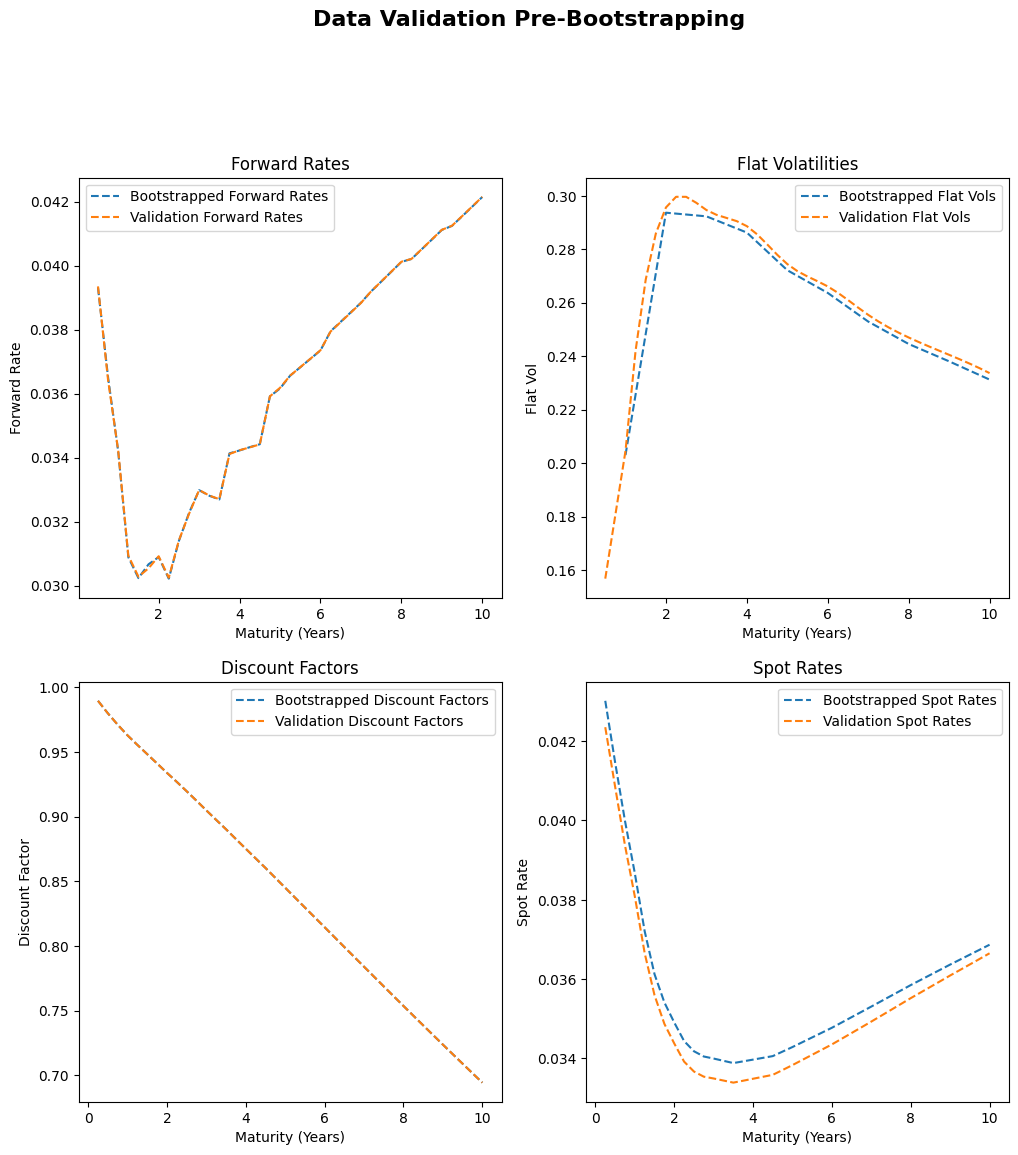

In [52]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

ax1 = axs[0, 0]
ax1.plot(Bootstrapped_Data['forward_rate'].index, Bootstrapped_Data['forward_rate'], label='Bootstrapped Forward Rates', linestyle='--')
ax1.plot(curves_validation['forwards'].index, curves_validation['forwards'], label='Validation Forward Rates', linestyle='--')
ax1.set_title('Forward Rates')
ax1.set_xlabel('Maturity (Years)')
ax1.set_ylabel('Forward Rate')
ax1.legend()

ax2 = axs[0, 1]
ax2.plot(Bootstrapped_Data['flat_vol'].index, Bootstrapped_Data['flat_vol'], label='Bootstrapped Flat Vols', linestyle='--')
ax2.plot(curves_validation['flat vols'].index, curves_validation['flat vols'], label='Validation Flat Vols', linestyle='--')
ax2.set_title('Flat Volatilities')
ax2.set_xlabel('Maturity (Years)')
ax2.set_ylabel('Flat Vol')
ax2.legend()    

ax3 = axs[1, 0]
ax3.plot(Bootstrapped_Data['discount_factors'].index, Bootstrapped_Data['discount_factors'], label='Bootstrapped Discount Factors', linestyle='--')
ax3.plot(curves_validation['discounts'].index, curves_validation['discounts'], label='Validation Discount Factors', linestyle='--')
ax3.set_title('Discount Factors')
ax3.set_xlabel('Maturity (Years)')
ax3.set_ylabel('Discount Factor')
ax3.legend() 

ax4 = axs[1, 1]
ax4.plot(Bootstrapped_Data['spot_rate'].index, Bootstrapped_Data['spot_rate'], label='Bootstrapped Spot Rates', linestyle='--')
ax4.plot(curves_validation['spot rates'].index, curves_validation['spot rates'], label='Validation Spot Rates', linestyle='--')
ax4.set_title('Spot Rates')
ax4.set_xlabel('Maturity (Years)')
ax4.set_ylabel('Spot Rate')
ax4.legend()

fig.suptitle("Data Validation Pre-Bootstrapping", fontsize=16, fontweight='bold', y=1.02)

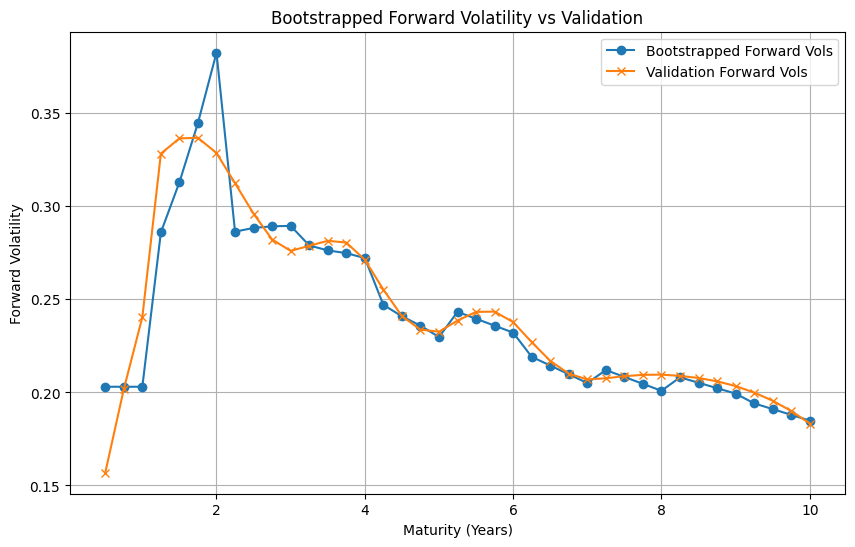

In [72]:
plt.figure(figsize=(10, 6))
plt.plot(forward_vols.index, forward_vols.values, label='Bootstrapped Forward Vols', marker='o')
plt.plot(curves_validation.index, curves_validation['fwd vols'], label='Validation Forward Vols', marker='x')
plt.xlabel('Maturity (Years)')
plt.ylabel('Forward Volatility')
plt.title('Bootstrapped Forward Volatility vs Validation')
plt.legend()
plt.grid()
plt.show()

#### - From the above outputs, it is clear that the derived forward, discount curve from swap rate, and interpolated swap and flat volatility data are quite close to the true value. 
#### - The bootstrapped forward vol has some deviations from the true forward vol at the early maturities (since 0.50, 0.75, 1.00 maturities Caps are not tradable), and eventually converges to the forward vol at later maturities 

## b)

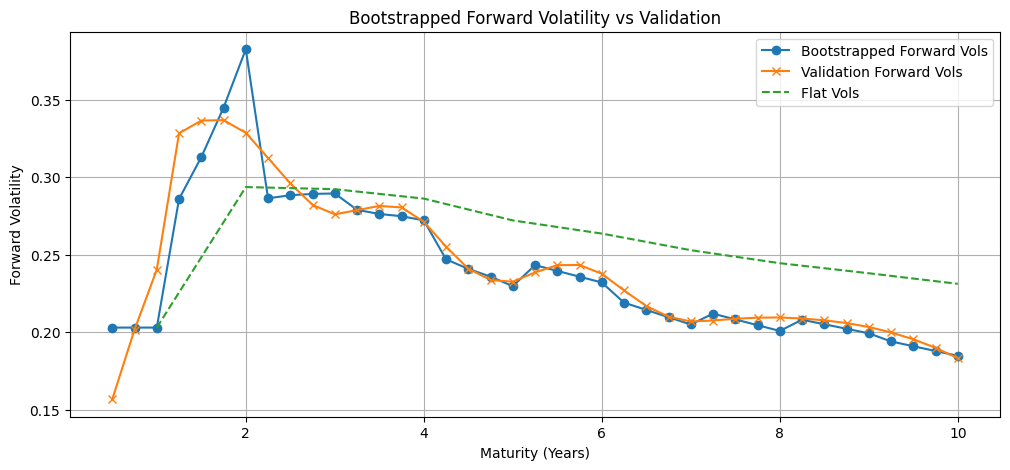

In [71]:
plt.Figure(figsize=(10, 6))
plt.plot(forward_vols.index, forward_vols.values, label='Bootstrapped Forward Vols', marker='o')
plt.plot(curves_validation.index, curves_validation['fwd vols'], label='Validation Forward Vols', marker='x')
plt.plot(quarterly_vols.index, quarterly_vols.values, label='Flat Vols', linestyle='--')
plt.xlabel('Maturity (Years)')
plt.ylabel('Forward Volatility')
plt.title('Bootstrapped Forward Volatility vs Validation')
plt.legend()
plt.grid()
plt.show()

#### - The bootstrapped forward vol curve is flat at ~20% for maturities under 1Y (by initialization convention), then humps sharply, peaking near 2Y at ~38% before declining monotonically to ~18% at 10Y. The hump reflects near-term policy uncertainty: as of June 2025, the Fed had paused its cutting cycle and markets were pricing significant uncertainty around the timing and magnitude of future cuts, which directly inflates the implied vol of caplets settling 1-2 years forward. Beyond 2Y, forward vols decline steadily as the market prices in eventual policy normalization — long-run rate volatility is anchored by mean reversion in short rates toward a neutral rate, compressing uncertainty at longer horizons.

## c)

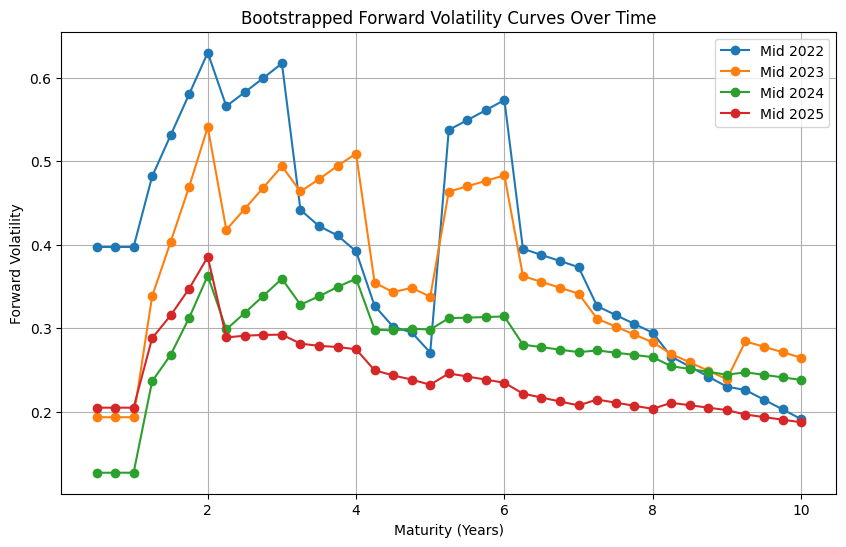

In [ ]:
def bootstrapping(cap_vols, SOFR_swaps):

    quarterly_swaps = pd.Series(index=np.arange(0.25, 10.25, 0.25), dtype=float)
    quarterly_swaps.loc[SOFR_swaps.index] = SOFR_swaps.values
    quarterly_swaps = quarterly_swaps.interpolate(method='index')

    # ── Step 2: Bootstrap discount factors ───────────────────────────────────────
    # SOFR swaps are annually compounded → convert to quarterly equivalent coupon
    # c = (1+R)^0.25 - 1  is the correct per-period coupon for a quarterly swap
    discount_factors = {}

    for T in sorted(quarterly_swaps.index):
        R = quarterly_swaps[T]
        c = (1 + R) ** 0.25 - 1          # quarterly coupon from annual compound rate

        known_sum = sum(discount_factors[t] * c for t in discount_factors)
        discount_factors[T] = (1 - known_sum) / (1 + c)

    discount_factors = pd.Series(discount_factors)

    # ── Step 3: Bootstrap simple forward rates ───────────────────────────────────
    # Simple rate convention: F = (DF_prev/DF_curr - 1) / dt
    # This is consistent with Black's formula for caplets
    forward_rates = {}
    tenors = sorted(discount_factors.index)

    for i in range(1, len(tenors)):
        T_prev = tenors[i - 1]
        T_curr = tenors[i]
        dt = T_curr - T_prev              # = 0.25 throughout
        forward_rates[(T_prev, T_curr)] = (
            discount_factors[T_prev] / discount_factors[T_curr] - 1
        ) / dt

    forward_rates = pd.Series(forward_rates)

    # ── Step 4: Convert strikes to simple rate convention ────────────────────────
    # Must match the convention of forward_rates before passing to Black's formula
    K_simple = quarterly_swaps.copy()
    K_simple = ((1 + K_simple) ** 0.25 - 1) / 0.25

    black_vols = {}
    for maturity in cap_vols.index:
        normal_vol = cap_vols[maturity] / 10000
        T_prev = round(maturity - 0.25, 2)
        F = forward_rates.get((T_prev, maturity), np.nan)  # forward ending at cap maturity
        black_vols[maturity] = normal_vol / F
    
    quarterly_vols = pd.Series(index = np.arange(0.5, 10.25, 0.25))
    quarterly_vols.loc[black_vols.keys()] = pd.Series(black_vols)
    quarterly_vols = quarterly_vols.interpolate(method='index') 

    cap_prices = {}

    for maturity in quarterly_vols.index:
        flat_vol = quarterly_vols.loc[maturity]
        caplet_maturities = np.arange(0.5, maturity + 0.25, 0.25)
        caplet_prices = []
        K = K_simple.loc[maturity]
        for T in caplet_maturities:
            T_expiry = T - 0.25
            forward_rate = forward_rates.get((T - 0.25, T), np.nan)
            discount_rate = discount_factors.get(T, np.nan)

            if np.isnan(forward_rate) or np.isnan(discount_rate):
                break

            d_1 = (np.log(forward_rate / K) + 0.5 * flat_vol**2 * (T_expiry)) / (flat_vol * np.sqrt(T_expiry))
            d_2 = d_1 - flat_vol * np.sqrt(T_expiry)

            caplet_price = discount_rate * (forward_rate * norm.cdf(d_1) - K * norm.cdf(d_2)) * 0.25
            caplet_prices.append(caplet_price)

        cap_prices[maturity] = sum(caplet_prices)

    cap_prices = pd.Series(cap_prices)

    caplet_prices = cap_prices.diff().dropna()
    

    forward_vols = bootstrap_forward_vols(cap_prices, forward_rates, discount_factors, K_simple, quarterly_vols)

    return forward_vols


mid_2022 = bootstrapping(cap_vols = cap_data.loc['2022-06-30'], SOFR_swaps = sofr_data.loc['2022-06-30'])
mid_2023 = bootstrapping(cap_vols = cap_data.loc['2023-06-30'], SOFR_swaps = sofr_data.loc['2023-06-30'])
mid_2024 = bootstrapping(cap_vols = cap_data.loc['2024-06-28'], SOFR_swaps = sofr_data.loc['2024-06-28']) 
mid_2025 = bootstrapping(cap_vols = cap_data.loc['2025-06-30'], SOFR_swaps = sofr_data.loc['2025-06-30'])
    
plt.figure(figsize=(10, 6))
plt.plot(mid_2022.index, mid_2022.values, label='Mid 2022', marker='o')
plt.plot(mid_2023.index, mid_2023.values, label='Mid 2023', marker='o')
plt.plot(mid_2024.index, mid_2024.values, label='Mid 2024', marker='o')
plt.plot(mid_2025.index, mid_2025.values, label='Mid 2025', marker='o')
plt.xlabel('Maturity (Years)')
plt.ylabel('Forward Volatility')
plt.title('Bootstrapped Forward Volatility Curves Over Time')
plt.legend()
plt.grid()
plt.show()

#### - Based on the boostrapped forward vol, it is clear that during mid-year each year, there is a consistent vol hump for interest rate instruments at 1.25-2 year maturities. However, contrary to 2025, in previous years, the forward vol curve also experienced a similar maginitute hump for interest rate instruments maturing at 5 - 6 year maturities. The most prominent is from mid-2022, where the invasion of Ukrain caused major uncertainty